In [1]:
import jax, diffrax, numpy
print(f"JAX: {jax.__version__}")
print(f"Diffrax: {diffrax.__version__}")
print(f"NumPy: {numpy.__version__}")
jax.config.update("jax_disable_jit", False)

import os

os.environ["CBEAM_BACKEND"] = "jax"

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import warnings
from scipy.fft import fft2, fftshift, ifftshift
from scipy.interpolate import RegularGridInterpolator, griddata
from scipy.ndimage import maximum_filter, map_coordinates
from scipy.optimize import linear_sum_assignment
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from matplotlib.patches import RegularPolygon

from cbeam.waveguide import PhotonicLantern, get_19port_positions
from cbeam.propagator import Propagator, ChainPropagator

warnings.filterwarnings('ignore')

JAX: 0.10.1
Diffrax: 0.7.2
NumPy: 2.4.6
Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython
Using JAX backend.
Using diffrax for ODE integration.


  Activating project at `~/dev/cbeam/src/cbeam/FEval`


In [2]:
def run_isolated_diagnostics(prop12, u0, current_backend):
    """
    Saves a baseline when run in NumPy mode, and compares numerical 
    divergence when run subsequently in JAX mode.
    """
    # Extract data from the first segment safely
    seg = prop12.get_prop(0)
    zi, zf = seg.zs[0], seg.zs[-1]
    
    # Run the actual forward propagation loop
    zs_curr, us_curr, uf_curr = prop12.propagate(u0)
    
    SAVE_FILE = "cbeam_numpy_baseline.npz"
    
    if current_backend == "numpy":
        # Capture baseline statistics
        int_neff_mid = seg.get_int_neff((zi + zf) / 2.0) - seg.get_int_neff(zi)
        np.savez(
            SAVE_FILE, 
            zs=np.array(zs_curr), 
            us=np.array(us_curr), 
            uf=np.array(uf_curr),
            int_neff_mid=np.array(int_neff_mid)
        )
        print(f"\n[Baseline Saved] NumPy path logged to {SAVE_FILE}. Now switch your backend to JAX and re-run.")
        
    elif current_backend == "jax":
        if not os.path.exists(SAVE_FILE):
            print(f"\n[Error] Baseline file '{SAVE_FILE}' not found. Run with NumPy backend first!")
            return
            
        # Load NumPy Baseline
        baseline = np.load(SAVE_FILE)
        zs_np = baseline['zs']
        us_np = baseline['us']
        uf_np = baseline['uf']
        int_neff_mid_np = baseline['int_neff_mid']
        
        print("\n--- Cross-Backend Numerical Verification ---")
        
        # 1. Continuous Phase Integral Check
        int_neff_mid_jax = seg.get_int_neff((zi + zf) / 2.0) - seg.get_int_neff(zi)
        phase_diff = np.max(np.abs(np.array(int_neff_mid_jax) - int_neff_mid_np))
        print(f"[Diagnostic] Phase Accumulation Max Error: {phase_diff:.4e}")
        
        # 2. End-State Solver Divergence Check
        # Interpolate JAX output grid onto NumPy grid endpoints for proper alignment
        uf_diff = np.linalg.norm(np.array(uf_curr) - uf_np)
        print(f"[Diagnostic] Final Output State (uf) L2 Diff: {uf_diff:.4e}")
        
        # 3. Plotting comparison
        plt.figure(figsize=(10, 4))
        plt.plot(zs_np, np.abs(us_np[:, 0]), label='NumPy Path (Baseline)', color='black', linestyle='--')
        plt.plot(zs_curr, np.abs(us_curr[:, 0]), label='JAX Path (Smooth Spline)', color='cyan', alpha=0.7)
        plt.title("Backend Solver Track Comparison: Mode 0 Magnitude")
        plt.xlabel("z")
        plt.ylabel("|u_0|")
        plt.legend()
        plt.show()


In [ ]:


# =====================================================================
# 1. CONFIGURATION & GEOMETRY DEFINITIONS
# =====================================================================

L1 = 50000
L2 = 50000

def get_simulation_parameters():
    """Returns a dictionary containing all setup constants and parameters."""
    params = {
        "wl": 0.8,                     # wavelength, um
        "wavelength_nm": 1550.0,       # simulation wavelength in nanometers
        "taper_factor": 12.,           # scale factor between front/back waveguide geometry
        "rclad": 9.0,                  # radius of cladding-jacket interface at frontside, um
        "rjack": 27,                   # radius of outer jacket boundary at frontside, um
        "z_ex": L1+L2,                # lantern length, um
        "nclad": 1.444,                # cladding refractive index
        "aberration_mode_idx": 3,      # Index for the atmospheric mode to distort
        "aberration_nm": 600.0,        # Aberration in nanometers of OPD
        "pad_factor": 4,               # Zero-padding multiplier for high-fidelity focal planes
        "core_res": 16,
        "clad_res": 60,
        "jack_res": 30,
        "ifunc_file": '/raid2/gcarla/git/ANDES/andes/PASSATA_scripts/data/ifunc/ANDES_400pix_all_modes.fits'
    }
    params["rcore"] = 1.8 / params["taper_factor"]
    params["ncore"] = params["nclad"] + 8.8e-3
    params["njack"] = params["nclad"] - 5.5e-3
    params["rcores"] = [params["rcore"]] * 19
    params["ncores"] = [params["ncore"]] * 19
    return params


# =====================================================================
# 2. WAVEGUIDE & BEAM PROPAGATION METHOD (BPM) STAGE
# =====================================================================
def build_and_characterize_lantern(p):
    """Sets up the PhotonicLantern object and builds the segmented ChainPropagator."""
    core_pos = get_19port_positions(p["rclad"] / 2.5)
    PL19 = PhotonicLantern(
        core_pos, p["rcores"], p["rclad"], p["rjack"], 
        p["ncores"], p["nclad"], p["njack"], p["z_ex"], 
        p["taper_factor"], p["core_res"], p["clad_res"], p["jack_res"]
    )
    
    # Propagator Segment 1: Front Section Characterization
    prop1 = Propagator(p["wl"], PL19, 20)
    prop1.degen_groups = [[1,2], [3,4], [6,7], [8,9], [10,11], [12,13], [15,16]]
    prop1.skipped_modes = [18]
        
    tag1 = "19port_0800_front"    
    prop1.characterize(0,L1,save=True,tag=tag1)
    #prop1.load(tag1)
    
    # Propagator Segment 2: Back Section Characterization
    prop2 = Propagator(p["wl"], PL19, 20)
    prop2.skipped_modes = [18]
    prop2.degen_groups = [[i for i in range(20)]]
    del prop2.degen_groups[0][18]
    
    tag2 = "19port_0800_back"

    # prop2.load_init_conds(prop1)    
    prop2.characterize(L1,L1+L2,save=True,tag=tag2)
    prop2.load(tag2)
 
    # Combine into sequential chain execution layout
    prop12 = ChainPropagator([prop1, prop2])
    return prop12


# =====================================================================
# 3. ATMOSPHERIC INTERACTION & PSF WAVEFRONT SAMPLING STAGE
# =====================================================================
def generate_incident_field_profile(p, ifunc, mesh_0):
    """Computes the phase-aberrated incoming PSF and returns the spatial interpolator."""
    mask_np = ifunc.mask_inf_func.get() > 0
    grid_size = mask_np.shape[0]
    
    # 1. Generate Combined 2D Pupil Phase Screen (OPD in nm)
    num_modes = len(ifunc.influence_function)
    my_coefficients = np.zeros(num_modes)
    my_coefficients[p["aberration_mode_idx"]] = p["aberration_nm"]
    
    opd_flat = np.zeros_like(ifunc.influence_function[0].get(), dtype=np.float64)
    for idx, coeff in enumerate(my_coefficients):
        if coeff != 0.0:
            opd_flat += coeff * ifunc.influence_function[idx].get()
            
    opd_2d = np.zeros((grid_size, grid_size), dtype=np.float64)
    opd_2d[mask_np] = opd_flat
    
    # Convert OPD map (nm) to Phase (radians)
    phase_2d_rad = opd_2d * (2.0 * np.pi / p["wavelength_nm"])
    
    # 2. Propagate to Focal Plane via FFT with Zero-Padding
    E_pupil = mask_np * np.exp(1j * phase_2d_rad)
    padded_grid_size = grid_size * p["pad_factor"]
    
    pad_top = (padded_grid_size - grid_size) // 2
    pad_bottom = padded_grid_size - grid_size - pad_top
    pad_left = (padded_grid_size - grid_size) // 2
    pad_right = padded_grid_size - grid_size - pad_left
    
    E_pupil_padded = np.pad(E_pupil, ((pad_top, pad_bottom), (pad_left, pad_right)), mode='constant', constant_values=0)
    
    E_focal_raw = fftshift(fft2(ifftshift(E_pupil_padded)))
    E_focal_raw /= np.sqrt(np.sum(np.abs(E_focal_raw)**2))
    
    # 3. Align Physical Grid Geometry Scales
    pupil_radius = np.sqrt(np.sum(mask_np) / np.pi)
    pixel_scale_lamD = padded_grid_size / (2.0 * pupil_radius)
    coords_lamD = np.arange(-padded_grid_size // 2, padded_grid_size // 2) / pixel_scale_lamD
    
    lamD_to_microns = p["rclad"] / 3.0
    focal_coords_microns = coords_lamD * lamD_to_microns
    
    # 4. Return continuous interpolation profile
    return RegularGridInterpolator(
        (focal_coords_microns, focal_coords_microns), 
        E_focal_raw, 
        bounds_error=False, 
        fill_value=0.0
    )


# =====================================================================
# 4. SUB-PIXEL CALIBRATION & CONTINUOUS SIGNAL COLLECTOR
# =====================================================================
def calibrate_subpixel_centers(waveguide_modes_final, mesh_final):
    """Finds core centers to sub-pixel accuracy using a center-of-mass centroid approach."""
    plot_x_out = np.linspace(mesh_final.points[:, 0].min(), mesh_final.points[:, 0].max(), 400)
    plot_y_out = np.linspace(mesh_final.points[:, 1].min(), mesh_final.points[:, 1].max(), 400)
    X_plot_out, Y_plot_out = np.meshgrid(plot_x_out, plot_y_out)
    
    dx = plot_x_out[1] - plot_x_out[0]
    dy = plot_y_out[1] - plot_y_out[0]
    
    total_modes_profile = np.sum(np.abs(waveguide_modes_final)**2, axis=0)
    total_modes_2d = griddata(
        (mesh_final.points[:, 0], mesh_final.points[:, 1]), total_modes_profile, 
        (X_plot_out, Y_plot_out), method='linear', fill_value=0.0
    )
    
    is_peak = (total_modes_2d == maximum_filter(total_modes_2d, size=21)) & (total_modes_2d > 0.1 * np.max(total_modes_2d))
    peak_rows, peak_cols = np.where(is_peak)
    
    core_centers = []
    centroid_half_width = 4
    
    for r, c in zip(peak_rows, peak_cols):
        r_min, r_max = max(0, r - centroid_half_width), min(total_modes_2d.shape[0], r + centroid_half_width + 1)
        c_min, c_max = max(0, c - centroid_half_width), min(total_modes_2d.shape[1], c + centroid_half_width + 1)
        
        patch = total_modes_2d[r_min:r_max, c_min:c_max]
        r_indices, c_indices = np.meshgrid(np.arange(r_min, r_max), np.arange(c_min, c_max), indexing='ij')
        
        patch_sum = np.sum(patch)
        if patch_sum > 0:
            sub_pixel_row = np.sum(r_indices * patch) / patch_sum
            sub_pixel_col = np.sum(c_indices * patch) / patch_sum
            cx = plot_x_out[0] + sub_pixel_col * dx
            cy = plot_y_out[0] + sub_pixel_row * dy
        else:
            cx, cy = plot_x_out[c], plot_y_out[r]
            
        core_centers.append((cx, cy))
        
    return sorted(core_centers, key=lambda p: (np.round(p[1], 2), np.round(p[0], 2))), plot_x_out, plot_y_out, dx, dy


def collect_subpixel_signals(image_2d, x_min, y_min, dx, dy, centers, n=7):
    """Extracts an n x n subimage centered on fractional continuous coordinates."""
    signals = np.zeros(len(centers))
    half_n = n // 2
    offsets = np.arange(-half_n, half_n + 1)
    
    for idx, (cx, cy) in enumerate(centers):
        f_col = (cx - x_min) / dx
        f_row = (cy - y_min) / dy
        
        sub_cols, sub_rows = np.meshgrid(f_col + offsets, f_row + offsets)
        coords = np.vstack((sub_rows.ravel(), sub_cols.ravel()))
        subimage_flat = map_coordinates(image_2d, coords, order=3, mode='constant', cval=0.0)
        signals[idx] = np.mean(subimage_flat)
        
    return signals


# =====================================================================
# 5. INTEGRITY GEOMETRIC ASSIGNMENT MATCHER (HUNGARIAN ALIGNMENT)
# =====================================================================
def map_evaluated_to_ideal_geometry(core_centers, ideal_centers_list):
    """Calculates optimal rigid alignment (Procrustes SVD) and assigns global indexes."""
    ideal_centers = np.array(ideal_centers_list)
    eval_centers = np.array(core_centers)
    
    ideal_centered = ideal_centers - np.mean(ideal_centers, axis=0)
    eval_centered = eval_centers - np.mean(eval_centers, axis=0)
    
    scale_ideal = np.sqrt(np.mean(np.sum(ideal_centered**2, axis=1)))
    scale_eval = np.sqrt(np.mean(np.sum(eval_centered**2, axis=1)))
    eval_scaled = eval_centered * (scale_ideal / scale_eval)
    
    H = np.dot(eval_scaled.T, ideal_centered)
    U, S, Vt = np.linalg.svd(H)
    R = np.dot(Vt.T, U.T)
    eval_aligned = np.dot(eval_scaled, R.T)
    
    diff = eval_aligned[:, np.newaxis, :] - ideal_centered[np.newaxis, :, :]
    cost_matrix = np.sqrt(np.sum(diff**2, axis=-1))
    eval_indices, ideal_permutation = linear_sum_assignment(cost_matrix)
    
    print(f"[Geometric Fit] Estimated physical core pitch: {scale_eval / scale_ideal:.3f} µm")
    print(f"[Geometric Fit] Residual matching RMS error: {np.mean(cost_matrix[eval_indices, ideal_permutation]):.4e}\n")
    
    return ideal_permutation


# =====================================================================
# 6. HIGH-LEVEL VISUALIZATION ENGINE
# =====================================================================
def display_hex_grid_plots(ideal_centers, standardized_signals):
    """Generates the concurrent side-by-side 3D column and 2D map views."""
    heights = standardized_signals * 1000
    centers = np.array(ideal_centers)
    hex_radius = 0.4
    
    vmin, vmax = heights.min(), heights.max()
    norm = plt.Normalize(vmin=vmin, vmax=vmax)
    cmap = plt.cm.viridis
    
    min_x, max_x = centers[:, 0].min() - 1, centers[:, 0].max() + 1
    min_y, max_y = centers[:, 1].min() - 1, centers[:, 1].max() + 1
    
    def create_hexagon_vertices(cx, cy, r):
        angles = np.linspace(0, 2 * np.pi, 7)[:-1]
        return np.column_stack((cx + r * np.cos(angles), cy + r * np.sin(angles)))

    fig = plt.figure(figsize=(18, 8))
    ax1 = fig.add_subplot(121, projection='3d')
    ax2 = fig.add_subplot(122)
    
    polys, colors_list, n_sides = [], [], 6
    for i, (x, y) in enumerate(centers):
        height = heights[i]
        color = cmap(norm(height))
        hex_vertices = create_hexagon_vertices(x, y, hex_radius)
        
        base_3d = np.column_stack((hex_vertices, np.zeros(n_sides)))
        top_3d = np.column_stack((hex_vertices, np.full(n_sides, height)))
        vertices_3d = np.vstack((base_3d, top_3d))
        
        polys.extend([vertices_3d[:n_sides], vertices_3d[n_sides:]])
        colors_list.extend([color, color])
        
        for j in range(n_sides):
            side_face = [vertices_3d[j], vertices_3d[(j+1)%n_sides], vertices_3d[(j+1)%n_sides + n_sides], vertices_3d[j + n_sides]]
            polys.append(side_face)
            colors_list.append(color)

    poly_collection = Poly3DCollection(polys, alpha=0.7, edgecolor='black', linewidth=0.5)
    poly_collection.set_facecolor(colors_list)
    ax1.add_collection3d(poly_collection)
    ax1.set_xlim(min_x, max_x); ax1.set_ylim(min_y, max_y); ax1.set_zlim(0, heights.max() * 1.1)
    ax1.set_xlabel('X'); ax1.set_ylabel('Y'); ax1.set_zlabel('Height')
    ax1.set_title('3D Height Field on Hexagonal Grid')
    
    for i, (x, y) in enumerate(centers):
        height = heights[i]
        hexagon = RegularPolygon((x, y), numVertices=6, radius=hex_radius, orientation=0,
                                 facecolor=cmap(norm(height)), edgecolor='black', linewidth=1.5, alpha=0.8)
        ax2.add_patch(hexagon)
        ax2.text(x, y, f'{height:.1f}', ha='center', va='center', fontsize=8, fontweight='bold')

    ax2.set_xlim(min_x, max_x); ax2.set_ylim(min_y, max_y); ax2.set_aspect('equal')
    ax2.set_xlabel('X', fontsize=12); ax2.set_ylabel('Y', fontsize=12)
    ax2.set_title('Top View: Hexagonal Grid Height Field', fontsize=14)
    ax2.grid(True, alpha=0.3)
    
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    fig.colorbar(sm, ax=[ax1, ax2], pad=0.05, shrink=0.7).set_label('Height', fontsize=12)
    plt.show()



In [4]:
import specula

# Initialize SPECULA (set the device index if needed)
specula.init(0)

from specula.data_objects.ifunc import IFunc

# B. System Configuration Setup
p = get_simulation_parameters()
print(p["ifunc_file"])
ifunc = IFunc.restore(p["ifunc_file"])

2026-05-30 15:42:37,988 [INFO]: [specula]: Cupy import successfull. Installed version is: 13.3.0
2026-05-30 15:42:37,992 [INFO]: [specula]: Default device is GPU number 0


/raid2/gcarla/git/ANDES/andes/PASSATA_scripts/data/ifunc/ANDES_400pix_all_modes.fits


In [5]:

# =====================================================================
# 7. MAIN SIMULATION EXECUTIVE PIPELINE
# =====================================================================

# A. Initial Ideal Grid Constraints Definition
ideal_grid_positions = [
    (0.0000, 0.0000), (1.0000, 0.0000), (0.5000, 0.8660), (-0.5000, 0.8660),
    (-1.0000, 0.0000), (-0.5000, -0.8660), (0.5000, -0.8660), (2.0000, 0.0000),
    (1.5000, 0.8660), (1.0000, 1.7321), (0.0000, 1.7321), (-1.0000, 1.7321),
    (-1.5000, 0.8660), (-2.0000, 0.0000), (-1.5000, -0.8660), (-1.0000, -1.7321),
    (0.0000, -1.7321), (1.0000, -1.7321), (1.5000, -0.8660)
]

# C. Build Propagation Medium & Mesh Properties
prop12 = build_and_characterize_lantern(p)
mesh_0 = prop12.make_mesh_at_z(0)
mesh_areas = mesh_0.areas if hasattr(mesh_0, 'areas') else 1.0
points_to_sample = np.stack((mesh_0.points[:, 1], mesh_0.points[:, 0]), axis=-1)

mesh_final = prop12.make_mesh_at_z(prop12.get_prop(0).zs[-1]) # Extracted terminal final length

# E. Overlap Integral Integration Projection
waveguide_modes = prop12.get_prop(0).vs[0]
if waveguide_modes.shape[0] == len(mesh_0.points[:, 0]):
    waveguide_modes = waveguide_modes.T

In [6]:
# D. Wavefront Aberrator Calculation
psf_interp = generate_incident_field_profile(p, ifunc, mesh_0)
E_input_spatial = psf_interp(points_to_sample).astype(np.complex128)
u0 = waveguide_modes.conj() @ (E_input_spatial * mesh_areas)
u0 /= np.linalg.norm(u0)
# F. Propagate Wavefront through Lantern Structure
print(f"Propagating {len(u0)} initial waveguide mode coefficients through the lantern...")

Propagating 20 initial waveguide mode coefficients through the lantern...



--- Cross-Backend Numerical Verification ---
[Diagnostic] Phase Accumulation Max Error: 2.1505e-02
[Diagnostic] Final Output State (uf) L2 Diff: 2.2142e-01


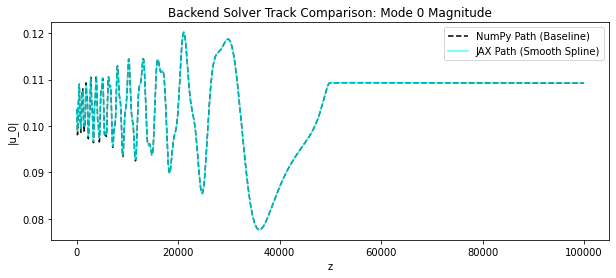

In [7]:
active_backend_string = prop12.get_prop(0).backend
run_isolated_diagnostics(prop12, u0, active_backend_string)

In [8]:
%%time
zs, us, uf = prop12.propagate(u0)

CPU times: user 3.55 s, sys: 578 ms, total: 4.12 s
Wall time: 1.67 s


In [9]:

waveguide_modes_final = prop12.get_prop(zs[-1]).vs[-1]
if waveguide_modes_final.shape[0] == len(mesh_final.points):
    waveguide_modes_final = waveguide_modes_final.T
E_output_spatial = uf @ waveguide_modes_final

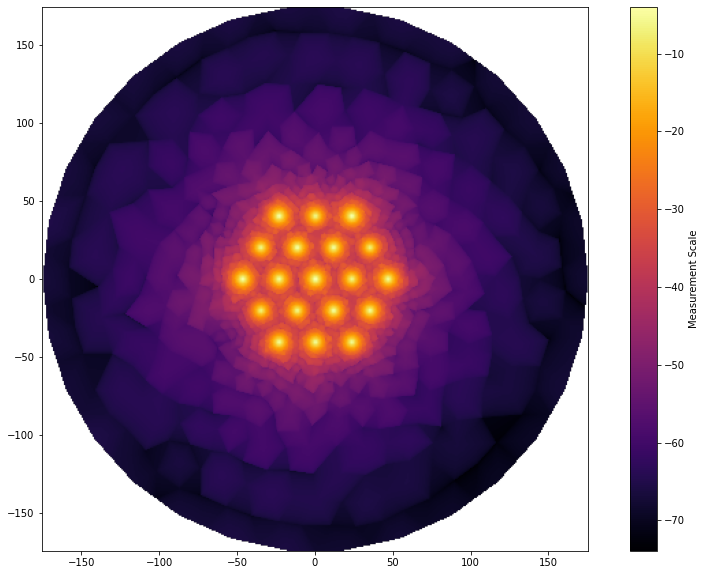

[Geometric Fit] Estimated physical core pitch: 23.396 µm
[Geometric Fit] Residual matching RMS error: 3.6200e-01



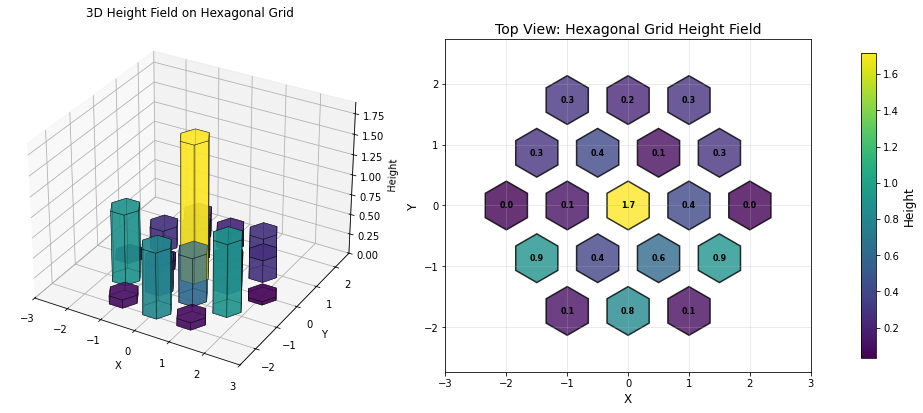

In [10]:
# G. Structural Fine Mesh Continuous Interpolation 
plot_x_out = np.linspace(mesh_final.points[:, 0].min(), mesh_final.points[:, 0].max(), 400)
plot_y_out = np.linspace(mesh_final.points[:, 1].min(), mesh_final.points[:, 1].max(), 400)
X_plot_out, Y_plot_out = np.meshgrid(plot_x_out, plot_y_out)

uf_2d = griddata(
    (mesh_final.points[:, 0], mesh_final.points[:, 1]), np.abs(E_output_spatial)**2, 
    (X_plot_out, Y_plot_out), method='linear', fill_value=0.0
)

# H. Execute Centroid Sub-Pixel Track and Signal Extraction
core_centers, plot_x_out, plot_y_out, dx, dy = calibrate_subpixel_centers(waveguide_modes_final, mesh_final)

output_signals = collect_subpixel_signals(uf_2d, plot_x_out[0], plot_y_out[0], dx, dy, core_centers, n=7)

uf_2d_log = np.log(np.abs(uf_2d))


plt.figure(figsize=(15, 10))

plt.imshow( uf_2d_log,
            cmap='inferno', 
            extent=[plot_x_out.min(), plot_x_out.max(), plot_y_out.min(), plot_y_out.max()],
            origin='lower',
           )
plt.colorbar(label='Measurement Scale') 
plt.show()


# I. Geometric Hex Matrix Permutation Sorting & Plotting Execution
ideal_permutation = map_evaluated_to_ideal_geometry(core_centers, ideal_grid_positions)

standardized_signals = np.zeros(19)
standardized_signals[ideal_permutation] = output_signals

# J. Display Output Plots
display_hex_grid_plots(ideal_grid_positions, standardized_signals)